In [38]:
import pandas as pd 
import numpy as np 
from sklearn.linear_model import Lasso
from scipy.stats import norm
import os
from sklearn.model_selection import KFold

In [39]:
data_path = os.path.join("..", "Data", "acemoglu64.csv")
dat = pd.read_csv(data_path)
print(f'The data contains {dat.shape[0]} rows (countries) and {dat.shape[1]} columns (variables).')

The data contains 58 rows (countries) and 45 columns (variables).


In [40]:
Y = dat['logpgp95']
A = dat['avexpr']
Z = dat['logem4']
X = dat.drop(columns=['logpgp95','avexpr','logem4'])

In [41]:
def standardize(X):
    X = np.asarray(X, dtype=float)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, ddof=1, keepdims=True)
    sd[sd == 0] = 1.0
    return (X - mu) / sd

def BCCH(X_tilde, y, c=1.1, alpha=0.05):
    X_tilde = np.asarray(X_tilde, dtype=float)
    y = np.asarray(y, dtype=float).flatten()
    N, p = X_tilde.shape    

    yXscale = (np.max((X_tilde.T ** 2) @ ((y-np.mean(y)) ** 2) / N)) ** 0.5
    lambda_pilot = c*norm.ppf(1-alpha/(2*p))*yXscale/np.sqrt(N)
    
    pred = Lasso(alpha=lambda_pilot).fit(X_tilde,y).predict(X_tilde)

    res = y - pred
    resXscale = (np.max((X_tilde.T ** 2) @ (res ** 2) / N)) ** 0.5
    lambda_bcch = c*norm.ppf(1-alpha/(2*p))*resXscale/np.sqrt(N)

    return lambda_bcch

In [42]:
X_tilde = standardize(X)


In [43]:
print("X_tilde shape:", X_tilde.shape)
print("Any NaN in X_tilde?", np.isnan(X_tilde).any())



X_tilde shape: (58, 42)
Any NaN in X_tilde? False


In [44]:
alpha = 0.05

# 1st LASSO: Y on X
lambda_Y = BCCH(X_tilde, Y, alpha=alpha)
lasso_Y = Lasso(alpha=lambda_Y, max_iter=12000).fit(X_tilde, Y)
coefs_Y = lasso_Y.coef_
sel_Y = np.where(coefs_Y != 0)[0]
# 2nd LASSO: A on X
lambda_A = BCCH(X_tilde, A, alpha=alpha) 
lasso_A = Lasso(alpha=lambda_A, max_iter=12000).fit(X_tilde, A)
coefs_A = lasso_A.coef_
sel_A = np.where(coefs_A != 0)[0]
# 3rd LASSO: Z on X
lambda_Z = BCCH(X_tilde, Z, alpha=alpha)
lasso_Z = Lasso(alpha=lambda_Z, max_iter=12000).fit(X_tilde, Z)
coefs_Z = lasso_Z.coef_
sel_Z = np.where(coefs_Z != 0)[0]
# Union of selected variables
sel_union = np.union1d(sel_Y, np.union1d(sel_A, sel_Z))
print(f'Selected variables indices: {sel_union}')

Selected variables indices: []


In [45]:
from sklearn.linear_model import Lasso
from scipy.stats import norm
import numpy as np

def BCCH_diag(X_tilde, y, c=1.1, alpha=0.05, max_iter=10000):
    # Make sure inputs are nice
    X_tilde = np.asarray(X_tilde, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    N, p = X_tilde.shape

    if p == 0:
        raise ValueError("X_tilde must have at least one column.")
    if N != y.shape[0]:
        raise ValueError(f"Row mismatch: X_tilde has {N} rows, y has {y.shape[0]}.")

    if not np.isfinite(X_tilde).all():
        raise ValueError("X_tilde contains NaN or inf.")
    if not np.isfinite(y).all():
        raise ValueError("y contains NaN or inf.")

    # Quantile term
    quant = norm.ppf(1 - alpha / (2 * p))

    # Pilot scale based on y
    y_centered = y - y.mean()
    yXscale = np.sqrt(np.max((X_tilde ** 2).T @ (y_centered ** 2) / N))
    lambda_pilot = c * quant * yXscale / np.sqrt(N)

    print("=== BCCH diagnostics ===")
    print(f"N             = {N}")
    print(f"p             = {p}")
    print(f"quantile term = {quant:.6f}")
    print(f"yXscale       = {yXscale:.6f}")
    print(f"lambda_pilot  = {lambda_pilot:.6f}")

    # Pilot Lasso
    fit_pilot = Lasso(alpha=lambda_pilot, max_iter=max_iter).fit(X_tilde, y)
    eps = y - fit_pilot.predict(X_tilde)

    # Final scale based on residuals
    epsXscale = np.sqrt(np.max((X_tilde ** 2).T @ (eps ** 2) / N))
    lambda_bcch = c * quant * epsXscale / np.sqrt(N)

    print(f"epsXscale     = {epsXscale:.6f}")
    print(f"lambda_bcch   = {lambda_bcch:.6f}")
    print("=========================\n")

    return float(lambda_bcch)
# Compute BCCH penalty with diagnostics
lambda_Y = BCCH_diag(X_tilde, Y)

# Fit Lasso and see selection
lasso_Y = Lasso(alpha=lambda_Y, max_iter=12000).fit(X_tilde, Y)
coefs_Y = lasso_Y.coef_
selected = np.where(coefs_Y != 0)[0]

print("BCCH lambda_Y:", lambda_Y)
print("Number of selected variables:", len(selected))
print("Selected indices:", selected)
for f in [1.0, 0.8, 0.2, 0.1]:
    lmb = lambda_Y * f
    lasso_tmp = Lasso(alpha=lmb, max_iter=12000).fit(X_tilde, Y)
    k_sel = np.sum(lasso_tmp.coef_ != 0)
    print(f"alpha = {lmb:.6f}, selected = {k_sel}")


=== BCCH diagnostics ===
N             = 58
p             = 42
quantile term = 3.241152
yXscale       = 1.850393
lambda_pilot  = 0.866247
epsXscale     = 1.850393
lambda_bcch   = 0.866247

BCCH lambda_Y: 0.866247462038237
Number of selected variables: 0
Selected indices: []
alpha = 0.866247, selected = 0
alpha = 0.692998, selected = 1
alpha = 0.173249, selected = 6
alpha = 0.086625, selected = 11


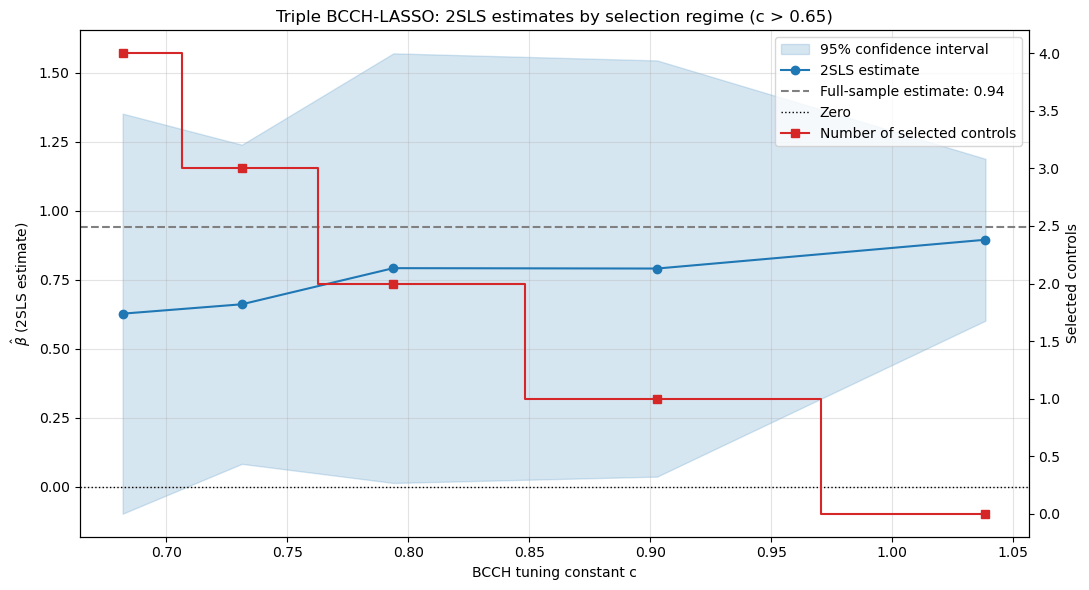

=== Regime-level summary (one row per union size) ===


,union_size,c_rep,beta_rep,ci_low_rep,ci_high_rep
0,4,0.681963,0.627011,-0.098032,1.352054
1,3,0.731222,0.661030,0.082637,1.239422
2,2,0.793836,0.791977,0.013432,1.570521
3,1,0.902786,0.790577,0.036307,1.544847
4,0,1.038481,0.894945,0.601678,1.188212


=== All stable points (c > 0.65, before collapsing) ===


,c,beta_hat,se_beta,ci_low,ci_high,union_size,cond_number,union_idx
37,0.658278,0.627011,0.369920,-0.098032,1.352054,4,35224.265052,"[27, 34, 36, 37]"
38,0.673822,0.627011,0.369920,-0.098032,1.352054,4,35224.265052,"[27, 34, 36, 37]"
39,0.689733,0.627011,0.369920,-0.098032,1.352054,4,35224.265052,"[27, 34, 36, 37]"
40,0.706019,0.627011,0.369920,-0.098032,1.352054,4,35224.265052,"[27, 34, 36, 37]"
41,0.722690,0.661030,0.295098,0.082637,1.239422,3,20688.578164,"[34, 36, 37]"
42,0.739754,0.661030,0.295098,0.082637,1.239422,3,20688.578164,"[34, 36, 37]"
43,0.757222,0.791977,0.397217,0.013432,1.570521,2,26384.573736,"[36, 37]"
44,0.775102,0.791977,0.397217,0.013432,1.570521,2,26384.573736,"[36, 37]"
45,0.793404,0.791977,0.397217,0.013432,1.570521,2,26384.573736,"[36, 37]"
46,0.812138,0.791977,0.397217,0.013432,1.570521,2,26384.573736,"[36, 37]"


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
import warnings
from statsmodels.sandbox.regression.gmm import IV2SLS

# ============================================================
# 1. Baseline BCCH lambdas (c0 = 1.1)
# ============================================================

c0 = 1.1
lambda_Y0 = float(BCCH(X_tilde, Y, c=c0))
lambda_A0 = float(BCCH(X_tilde, A, c=c0))
lambda_Z0 = float(BCCH(X_tilde, Z, c=c0))

N, p = X_tilde.shape

# ============================================================
# 2. Grid over c via multiplicative factors
# ============================================================

n_points = 60
c_factors = np.logspace(-0.598, 0, n_points)   # relative to c0
c_values = []

betas = []
ses = []
union_sizes = []
union_sets = []
conds = []

lam_Y_list = []
lam_A_list = []
lam_Z_list = []

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for f in c_factors:
        # λ(f) = f × λ_BCCH  (equivalent to scaling c)
        lam_Y = f * lambda_Y0
        lam_A = f * lambda_A0
        lam_Z = f * lambda_Z0

        lam_Y_list.append(lam_Y)
        lam_A_list.append(lam_A)
        lam_Z_list.append(lam_Z)

        c_val = f * c0
        c_values.append(c_val)

        # 3 LASSOs
        lasso_y = Lasso(alpha=lam_Y, max_iter=80000, tol=1e-7).fit(X_tilde, Y)
        lasso_a = Lasso(alpha=lam_A, max_iter=80000, tol=1e-7).fit(X_tilde, A)
        lasso_z = Lasso(alpha=lam_Z, max_iter=80000, tol=1e-7).fit(X_tilde, Z)

        S_y = set(np.where(lasso_y.coef_ != 0)[0])
        S_a = set(np.where(lasso_a.coef_ != 0)[0])
        S_z = set(np.where(lasso_z.coef_ != 0)[0])

        S_union = sorted(S_y | S_a | S_z)
        union_sets.append(S_union)
        union_sizes.append(len(S_union))

        # Controls matrix for this c
        X_union = X_tilde[:, S_union] if S_union else np.empty((N, 0))

        # 2SLS with union controls
        if X_union.size > 0:
            exog = np.column_stack([np.ones(N), A, X_union])
            instr = np.column_stack([np.ones(N), Z, X_union])
        else:
            exog = np.column_stack([np.ones(N), A])
            instr = np.column_stack([np.ones(N), Z])

        # Condition number of X' Pz X
        Zm = instr
        Pz = Zm @ np.linalg.inv(Zm.T @ Zm) @ Zm.T
        XPZX = exog.T @ Pz @ exog
        cond_val = np.linalg.cond(XPZX)
        conds.append(cond_val)

        # 2SLS estimate + SE
        try:
            iv = IV2SLS(Y, exog, instr).fit()
            beta_hat = float(iv.params.iloc[1])   # coef on A
            se_hat   = float(iv.bse.iloc[1])      # SE on coef
        except Exception:
            beta_hat = np.nan
            se_hat   = np.nan

        betas.append(beta_hat)
        ses.append(se_hat)

# ============================================================
# 3. Convert to arrays, compute CI
# ============================================================

c_values = np.array(c_values)
betas = np.array(betas)
ses = np.array(ses)
union_sizes = np.array(union_sizes)
conds = np.array(conds)

lam_Y_arr = np.array(lam_Y_list)
lam_A_arr = np.array(lam_A_list)
lam_Z_arr = np.array(lam_Z_list)

ci_low = betas - 1.96 * ses
ci_high = betas + 1.96 * ses

# ============================================================
# 4. "Reasonable region": c > 0.65 + basic sanity
# ============================================================

stable_mask = (
    np.isfinite(betas) &
    np.isfinite(ses) &
    (c_values > 0.65) &
    (ses < 10) &
    (conds < 1e7)
)

df_stable = pd.DataFrame({
    "c": c_values,
    "beta_hat": betas,
    "se_beta": ses,
    "ci_low": ci_low,
    "ci_high": ci_high,
    "union_size": union_sizes,
    "cond_number": conds,
    "union_idx": union_sets,
})[stable_mask]

# ============================================================
# 4b. Collapse to ONE row per distinct union_size (for plotting)
# ============================================================

df_plot = (
    df_stable
    .groupby("union_size", as_index=False)
    .agg(
        c_rep=("c", "mean"),
        beta_rep=("beta_hat", "mean"),
        ci_low_rep=("ci_low", "mean"),
        ci_high_rep=("ci_high", "mean"),
    )
).sort_values("c_rep").reset_index(drop=True)

c_plot = df_plot["c_rep"].to_numpy()
beta_plot = df_plot["beta_rep"].to_numpy()
ci_low_plot = df_plot["ci_low_rep"].to_numpy()
ci_high_plot = df_plot["ci_high_rep"].to_numpy()
union_plot = df_plot["union_size"].to_numpy()

# ============================================================
# 5. Plot: regime-level β(c) + CI + union size
# ============================================================

beta_full = 0.94  # full-sample 2SLS estimate

plt.figure(figsize=(11, 6))
ax1 = plt.gca()

# CI band
ax1.fill_between(
    c_plot, ci_low_plot, ci_high_plot,
    color="#1f77b4", alpha=0.18,
    label="95% confidence interval"
)

# β(c)
ax1.plot(
    c_plot, beta_plot, "-o", color="#1f77b4",
    label="2SLS estimate"
)

# Full-sample beta
ax1.axhline(
    beta_full, linestyle="--", color="grey",
    label=f"Full-sample estimate: {beta_full:.2f}"
)

# Zero line
ax1.axhline(
    0.0, linestyle=":", color="black", linewidth=1.0,
    label="Zero"
)

ax1.set_xlabel("BCCH tuning constant c")
ax1.set_ylabel(r"$\hat{\beta}$ (2SLS estimate)")

ax1.grid(True, which="both", alpha=0.35)

# Make sure 0 is inside left y-axis range
y1_min, y1_max = ax1.get_ylim()
if y1_min > 0:
    y1_min = 0.0
if y1_max < 0:
    y1_max = 0.0
ax1.set_ylim(y1_min, y1_max)

# Right axis: union size
ax2 = ax1.twinx()
ax2.step(
    c_plot, union_plot, where="mid",
    color="#d62728", marker="s",
    label="Number of selected controls"
)
ax2.set_ylabel("Selected controls")

# Make sure 0 is inside right y-axis range as well
y2_min, y2_max = ax2.get_ylim()
if y2_min > 0:
    y2_min = 0.0
if y2_max < 0:
    y2_max = 0.0
ax2.set_ylim(y2_min, y2_max)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="best", frameon=True)

plt.title("Triple BCCH-LASSO: 2SLS estimates by selection regime (c > 0.65)")
plt.tight_layout()
plt.show()

# ============================================================
# 6. Results tables
# ============================================================

print("=== Regime-level summary (one row per union size) ===")
display(df_plot)

print("=== All stable points (c > 0.65, before collapsing) ===")
display(df_stable.sort_values("c"))


In [47]:
# 1) Get variable names from your X DataFrame
X_names = X.columns.to_list()
assert X_tilde.shape[1] == len(X_names), "X_tilde and X.columns length mismatch"

# Helper: indices -> names
def indices_to_names(idxs):
    return [X_names[j] for j in idxs]

# 2) Build one representative row per union_size regime
regime_rows = []
for u in sorted(df_stable["union_size"].unique()):
    sub = df_stable[df_stable["union_size"] == u].sort_values("c")
    row = sub.iloc[0]   # take first c in this regime as representative
    idxs = row["union_idx"]          # this is the list of selected column indices
    varnames = indices_to_names(idxs)

    regime_rows.append({
        "union_size": int(u),
        "c_rep": float(row["c"]),
        "beta_rep": float(row["beta_hat"]),
        "ci_low_rep": float(row["ci_low"]),
        "ci_high_rep": float(row["ci_high"]),
        "variables": varnames
    })

df_regimes = pd.DataFrame(regime_rows).sort_values("c_rep").reset_index(drop=True)
display(df_regimes)

# 3) LaTeX table
def latex_escape(s: str) -> str:
    return s.replace("_", r"\_")  # basic escaping; extend if needed

lines = []
lines.append(r"\begin{table}[h]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{ccccp{7cm}}")
lines.append(r"\toprule")
lines.append(r"Regime & $c$ & Union size & $\hat\beta_A$ (95\% CI) & Selected controls \\")
lines.append(r"\midrule")

for i, row in df_regimes.iterrows():
    c_val = f"{row['c_rep']:.3f}"
    u_sz = int(row["union_size"])
    beta = row["beta_rep"]
    ci_l = row["ci_low_rep"]
    ci_h = row["ci_high_rep"]
    ci_str = f"{beta:.2f} [{ci_l:.2f}, {ci_h:.2f}]"
    if u_sz > 0:
        vars_joined = ", ".join(latex_escape(v) for v in row["variables"])
    else:
        vars_joined = r"(none)"
    lines.append(
        f"{i+1} & {c_val} & {u_sz} & {ci_str} & {vars_joined} \\\\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Triple BCCH-LASSO selection regimes for $c>0.65$, "
             r"showing union size, 2SLS estimate of $A$, and selected controls.}")
lines.append(r"\label{tab:bcch_regimes}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)



,union_size,c_rep,beta_rep,ci_low_rep,ci_high_rep,variables
0,4,0.658278,0.627011,-0.098032,1.352054,"[edes1975, malfal94, leb95, imr95]"
1,3,0.722690,0.661030,0.082637,1.239422,"[malfal94, leb95, imr95]"
2,2,0.757222,0.791977,0.013432,1.570521,"[leb95, imr95]"
3,1,0.850944,0.790577,0.036307,1.544847,[imr95]
4,0,0.978847,0.894945,0.601678,1.188212,[]


\begin{table}[h]
\centering
\begin{tabular}{ccccp{7cm}}
\toprule
Regime & $c$ & Union size & $\hat\beta_A$ (95\% CI) & Selected controls \\
\midrule
1 & 0.658 & 4 & 0.63 [-0.10, 1.35] & edes1975, malfal94, leb95, imr95 \\
2 & 0.723 & 3 & 0.66 [0.08, 1.24] & malfal94, leb95, imr95 \\
3 & 0.757 & 2 & 0.79 [0.01, 1.57] & leb95, imr95 \\
4 & 0.851 & 1 & 0.79 [0.04, 1.54] & imr95 \\
5 & 0.979 & 0 & 0.89 [0.60, 1.19] & (none) \\
\bottomrule
\end{tabular}
\caption{Triple BCCH-LASSO selection regimes for $c>0.65$, showing union size, 2SLS estimate of $A$, and selected controls.}
\label{tab:bcch_regimes}
\end{table}


In [ ]:
# Example: list of column names for X_tilde in order
X_names = X.columns.to_list()  # e.g. ["africa", "lat_abst", "other", "asia", ..., "lt100km", "latabs"]

name_to_idx = {name: j for j, name in enumerate(X_names)}

blocks = {
    "region_colonial": [
        "africa", "asia", "other", "rich4",
        "f_brit", "f_french", "sjlofr",
    ],
    "culture_religion": [
        "catho80", "muslim80", "no_cpm80", "avelf", "edes1975",
    ],
    "climate": [
        "lat_abst", "latabs",
        "temp1", "temp2", "temp3", "temp4", "temp5",
        "humid1", "humid2", "humid3", "humid4",
        "meantemp", "drystep", "drywint",
    ],
    "soil_terrain": [
        "steplow", "deslow", "stepmid", "desmid",
    ],
    "geography": [
        "landlock", "lt100km",
    ],
    "resources": [
        "goldm", "iron", "silv", "zinc", "oilres",
    ],
    "disease": [
        "malfal94", "yellow",
    ],
    "health": [
        "leb95", "imr95",
    ],
}


In [50]:
from sklearn.linear_model import Lasso
from sklearn.exceptions import ConvergenceWarning
from statsmodels.sandbox.regression.gmm import IV2SLS
import warnings
import numpy as np

global_selected = set()

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for block_name, varnames in blocks.items():
        idxs = [name_to_idx[v] for v in varnames if v in name_to_idx]
        if not idxs:
            continue

        X_block = X_tilde[:, idxs]

        # You can choose one lambda per equation, e.g. BCCH for this block
        lam_Y = float(BCCH(X_block, Y))
        lam_A = float(BCCH(X_block, A))
        lam_Z = float(BCCH(X_block, Z))

        # Triple LASSO on this block
        lasso_y = Lasso(alpha=lam_Y, max_iter=80000, tol=1e-7).fit(X_block, Y)
        lasso_a = Lasso(alpha=lam_A, max_iter=80000, tol=1e-7).fit(X_block, A)
        lasso_z = Lasso(alpha=lam_Z, max_iter=80000, tol=1e-7).fit(X_block, Z)

        S_y = set(np.where(lasso_y.coef_ != 0)[0])
        S_a = set(np.where(lasso_a.coef_ != 0)[0])
        S_z = set(np.where(lasso_z.coef_ != 0)[0])

        # Indices relative to full X_tilde:
        S_block_union = {idxs[j] for j in (S_y | S_a | S_z)}

        print(block_name, "selected:",
              [X_names[j] for j in sorted(S_block_union)])

        global_selected |= S_block_union

# Final union of selected controls across all blocks
global_selected = sorted(global_selected)
print("Global selected controls:",
      [X_names[j] for j in global_selected])

# Build final X_union
N = X_tilde.shape[0]
X_union = X_tilde[:, global_selected] if global_selected else np.empty((N, 0))

# Final 2SLS
if X_union.size > 0:
    exog = np.column_stack([np.ones(N), A, X_union])
    instr = np.column_stack([np.ones(N), Z, X_union])
else:
    exog = np.column_stack([np.ones(N), A])
    instr = np.column_stack([np.ones(N), Z])

iv_final = IV2SLS(Y, exog, instr).fit()
beta_final = float(iv_final.params.iloc[1])
se_final = float(iv_final.bse.iloc[1])

print("Final 2SLS after blockwise selection: beta =", beta_final, "SE =", se_final)


region_colonial selected: []
culture_religion selected: ['edes1975']
climate selected: []
soil_terrain selected: []
geography selected: []
resources selected: []
disease selected: ['malfal94']
health selected: ['leb95', 'imr95']
Global selected controls: ['edes1975', 'malfal94', 'leb95', 'imr95']
Final 2SLS after blockwise selection: beta = 0.627010903094996 SE = 0.36991989245658197
